# Customer Segmentation and Predictive Analytics Using Machine Learning
**Course:** R Programming Lab | **Platform:** Google Colab (Python) | **Dataset:** UCI Online Retail

**Name:** Vicky Pukale   **Roll No:** 23102A0033   **Git Repo:** https://github.com/vickypukale/23102A0033_R_PROGRAMMING/tree/main/EXP_7

---
## 1. Problem Statement
An e-commerce company wants to better understand its customers and improve marketing decisions. Using historical online retail transactions, we will:

1. Preprocess the data and engineer customer-level features (RFM, average transaction value, quantity, purchase frequency).
2. Segment customers with **K-Means** (Elbow Method) and compare with **Hierarchical Clustering** (dendrogram), validating with the **Silhouette Score**.
3. Visualise segments with **PCA** (2D) and an interactive **Plotly 3D** plot, and profile each cluster.
4. Identify a **high-value segment** and predict membership with **Random Forest** and **SVM**, evaluated with Accuracy, Precision, Recall, F1, ROC-AUC and Confusion Matrix.
5. Analyse feature importance and recommend segment-wise marketing strategies.

## 2. Dataset Description
UCI Machine Learning Repository, *Online Retail* dataset (id 352): 541,909 transactions of a UK-based online retailer (Dec 2010 to Dec 2011).

| Column | Meaning |
|---|---|
| InvoiceNo | Invoice id (starts with **C** if the transaction is a cancellation) |
| StockCode | Product code |
| Description | Product name |
| Quantity | Units per transaction |
| InvoiceDate | Date and time of the invoice |
| UnitPrice | Price per unit (GBP) |
| CustomerID | Customer id (about 25% missing) |
| Country | Customer country |

## 3. Setup

In [1]:
%pip install -q ucimlrepo openpyxl plotly

import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, adjusted_rand_score, accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, classification_report)
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 4. Data Loading

In [2]:
try:
    from ucimlrepo import fetch_ucirepo
    df = fetch_ucirepo(id=352).data.original.copy()
except Exception as e:
    print("ucimlrepo failed, falling back to direct download:", e)
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx"
    df = pd.read_excel(url)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print(df.dtypes, "\n")
print("Missing values per column:\n", df.isna().sum(), "\n")
print("Cancelled invoices:", df["InvoiceNo"].astype(str).str.startswith("C").sum())
print("Rows with Quantity <= 0:", (df["Quantity"] <= 0).sum(), "| UnitPrice <= 0:", (df["UnitPrice"] <= 0).sum())
print("Duplicate rows:", df.duplicated().sum())
df.describe()

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object 

Missing values per column:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64 

Cancelled invoices: 9288
Rows with Quantity <= 0: 10624 | UnitPrice <= 0: 2517
Duplicate rows: 5268


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## 5. Data Preprocessing
Steps and justification:
- **Missing CustomerID**: rows cannot be attributed to a customer, so they are dropped.
- **Cancellations** (InvoiceNo starting with `C`, negative quantity): removed so they do not distort spend and frequency.
- **Invalid values** (`UnitPrice <= 0`, `Quantity <= 0`): removed (free samples, adjustments, bad debt).
- **Non-product stock codes** (POST, DOT, M, BANK CHARGES, etc.): removed, since they are fees, not purchases.
- **Exact duplicates**: removed.

In [4]:
n0 = len(df)
clean = df.dropna(subset=["CustomerID"]).copy()
clean["InvoiceNo"] = clean["InvoiceNo"].astype(str)
clean = clean[~clean["InvoiceNo"].str.startswith("C")]
clean = clean[(clean["Quantity"] > 0) & (clean["UnitPrice"] > 0)]
non_product = r"^(POST|D|DOT|M|BANK CHARGES|CRUK|S|AMAZONFEE|B|PADS)$"
clean = clean[~clean["StockCode"].astype(str).str.upper().str.match(non_product)]
clean = clean.drop_duplicates()
clean["CustomerID"] = clean["CustomerID"].astype(int)
clean["TotalPrice"] = clean["Quantity"] * clean["UnitPrice"]

print(f"Rows: {n0:,} -> {len(clean):,} ({len(clean)/n0:.1%} retained)")
print("Customers:", clean["CustomerID"].nunique(), "| Invoices:", clean["InvoiceNo"].nunique())

Rows: 541,909 -> 391,283 (72.2% retained)
Customers: 4334 | Invoices: 18405


## 6. Customer-Level Feature Engineering
| Feature | Definition |
|---|---|
| **Recency** | Days since last purchase (snapshot = last date + 1 day) |
| **Frequency** | Number of distinct invoices |
| **Monetary** | Total spend |
| **AvgTransactionValue** | Monetary / Frequency |
| **TotalQuantity** | Total units bought |
| **AvgQuantityPerInvoice** | TotalQuantity / Frequency |
| **PurchaseFrequency** | Invoices per 30 days of active tenure (tenure floored at one month) |
| **UniqueProducts** | Number of distinct products bought |

In [5]:
snapshot = clean["InvoiceDate"].max() + pd.Timedelta(days=1)
g = clean.groupby("CustomerID")
cust = pd.DataFrame({
    "Recency": (snapshot - g["InvoiceDate"].max()).dt.days,
    "Frequency": g["InvoiceNo"].nunique(),
    "Monetary": g["TotalPrice"].sum(),
    "TotalQuantity": g["Quantity"].sum(),
    "UniqueProducts": g["StockCode"].nunique(),
})
tenure_days = (g["InvoiceDate"].max() - g["InvoiceDate"].min()).dt.days + 1
cust["AvgTransactionValue"] = cust["Monetary"] / cust["Frequency"]
cust["AvgQuantityPerInvoice"] = cust["TotalQuantity"] / cust["Frequency"]
cust["PurchaseFrequency"] = cust["Frequency"] / np.maximum(tenure_days / 30, 1)

print("Customers:", cust.shape[0])
cust.describe().T.round(2)

Customers: 4334


,count,mean,std,min,25%,50%,75%,max
Recency,4334.0,92.70,100.18,1.00,18.00,51.00,143.00,374.00
Frequency,4334.0,4.25,7.64,1.00,1.00,2.00,5.00,206.00
Monetary,4334.0,2017.52,8920.36,3.75,304.30,663.71,1631.62,279138.02
TotalQuantity,4334.0,1186.41,5040.96,1.00,159.25,377.50,989.75,196844.00
UniqueProducts,4334.0,61.43,85.31,1.00,16.00,35.00,77.00,1786.00
AvgTransactionValue,4334.0,415.67,1800.86,3.75,177.20,289.77,423.77,84236.25
AvgQuantityPerInvoice,4334.0,255.25,1316.36,1.00,92.52,161.00,271.98,74215.00
PurchaseFrequency,4334.0,1.03,0.90,0.16,0.61,1.00,1.00,34.00


## 7. Outlier Treatment and Feature Scaling
The features are heavily right-skewed (a few customers spend enormous amounts). K-Means and PCA are distance/variance based, so:
1. **Log transform** (`log1p`) to reduce skew.
2. **IQR capping (winsorising)** at Q1 - 1.5 IQR and Q3 + 1.5 IQR on the logged values, which keeps every customer but limits extreme influence.
3. **Standardisation** (z-score) so that all features contribute equally to distances.

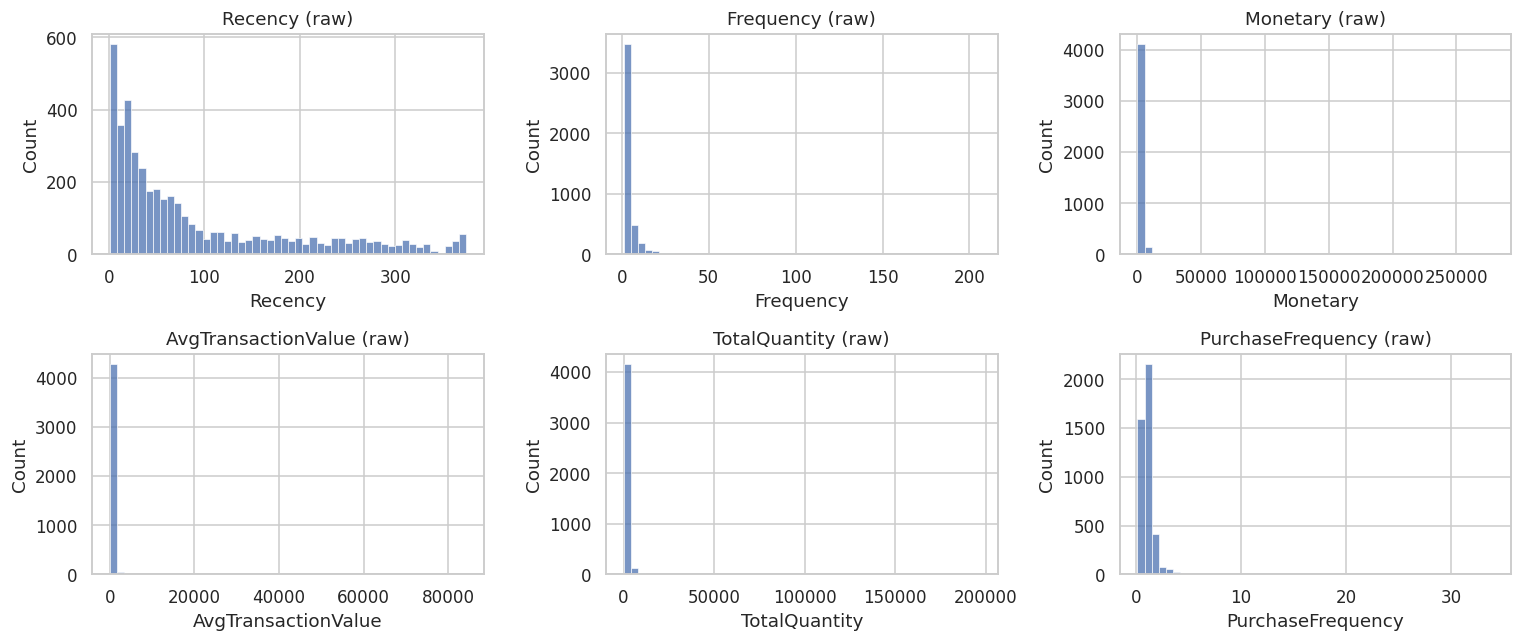

In [6]:
cluster_features = ["Recency", "Frequency", "Monetary", "AvgTransactionValue", "TotalQuantity", "PurchaseFrequency"]

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, c in zip(axes.ravel(), cluster_features):
    sns.histplot(cust[c], bins=50, ax=ax); ax.set_title(f"{c} (raw)")
plt.tight_layout(); plt.show()

Values capped per feature: {'Recency': 0, 'Frequency': 42, 'Monetary': 52, 'AvgTransactionValue': 130, 'TotalQuantity': 63, 'PurchaseFrequency': 488}


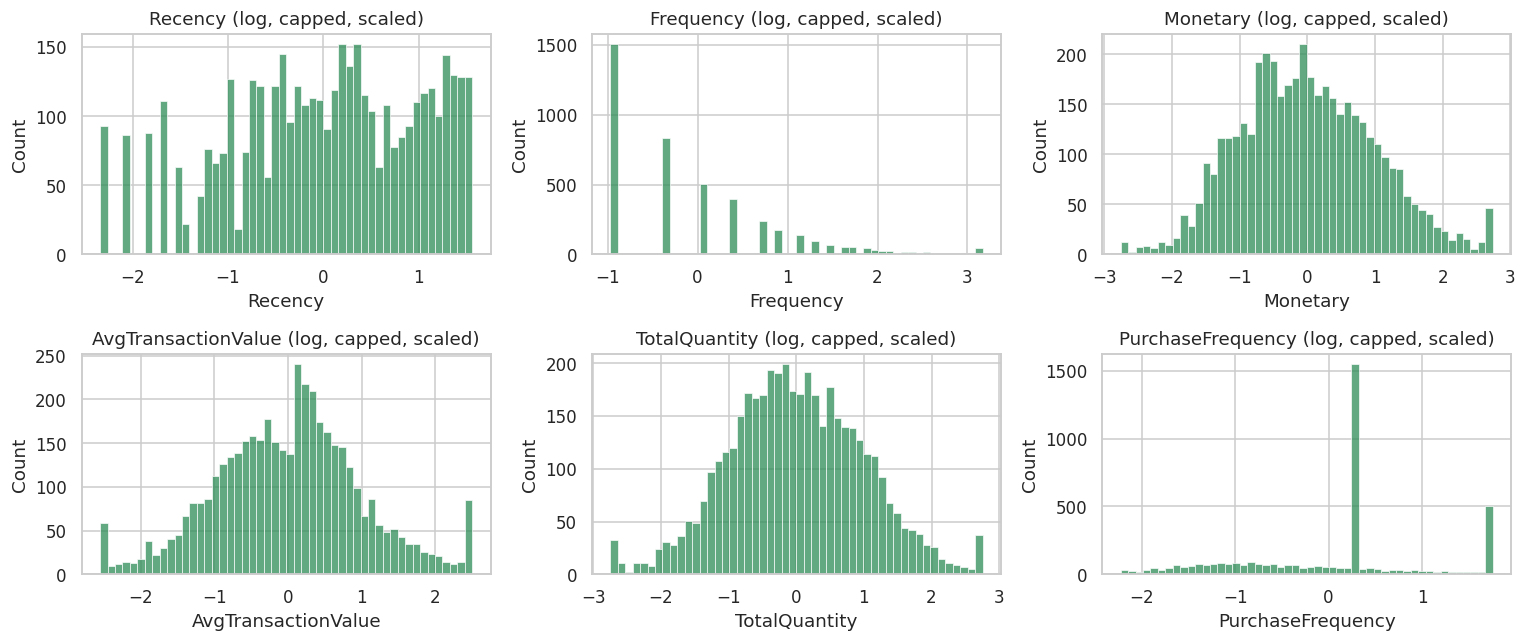

In [7]:
logged = np.log1p(cust[cluster_features])

capped = logged.copy()
n_capped = {}
for c in cluster_features:
    q1, q3 = logged[c].quantile([0.25, 0.75]); iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_capped[c] = int(((logged[c] < lo) | (logged[c] > hi)).sum())
    capped[c] = logged[c].clip(lo, hi)
print("Values capped per feature:", n_capped)

scaler = StandardScaler()
X = scaler.fit_transform(capped)
X_df = pd.DataFrame(X, index=cust.index, columns=cluster_features)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, c in zip(axes.ravel(), cluster_features):
    sns.histplot(X_df[c], bins=50, ax=ax, color="seagreen"); ax.set_title(f"{c} (log, capped, scaled)")
plt.tight_layout(); plt.show()

## 8. K-Means Clustering and the Elbow Method

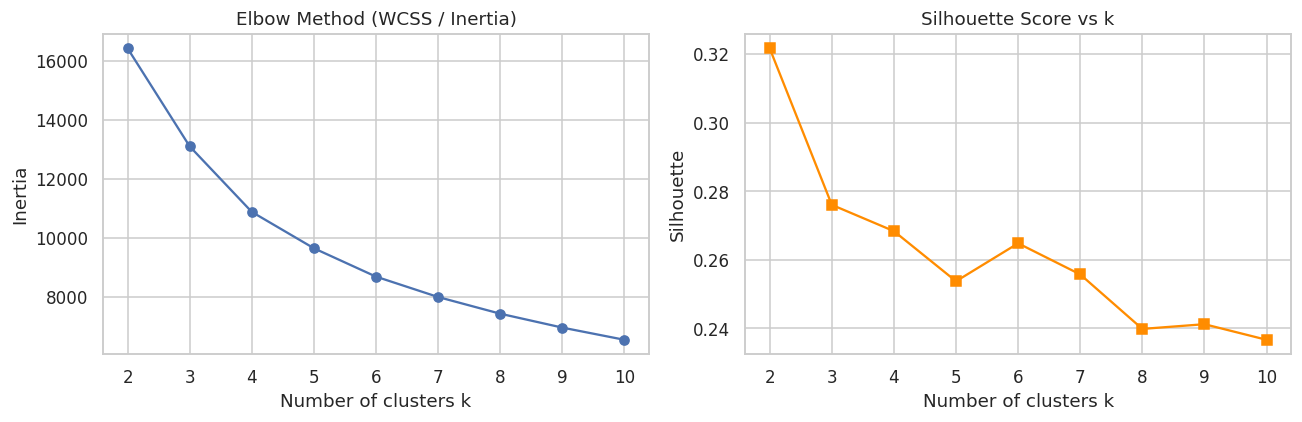

,k,Inertia,Silhouette
0,2,16412.0,0.3216
1,3,13092.1,0.2760
2,4,10873.3,0.2683
3,5,9642.5,0.2537
4,6,8682.2,0.2648
5,7,7992.0,0.2557
6,8,7427.0,0.2398
7,9,6956.6,0.2412
8,10,6543.7,0.2366


In [8]:
K_RANGE = range(2, 11)
inertias, sils = [], []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(K_RANGE), inertias, "o-"); ax[0].set_title("Elbow Method (WCSS / Inertia)")
ax[0].set_xlabel("Number of clusters k"); ax[0].set_ylabel("Inertia")
ax[1].plot(list(K_RANGE), sils, "s-", color="darkorange"); ax[1].set_title("Silhouette Score vs k")
ax[1].set_xlabel("Number of clusters k"); ax[1].set_ylabel("Silhouette")
plt.tight_layout(); plt.show()

pd.DataFrame({"k": list(K_RANGE), "Inertia": np.round(inertias, 1), "Silhouette": np.round(sils, 4)})

**Choosing k.** The elbow is where the drop in inertia flattens, and it should be read together with the silhouette curve. The cell below picks the k in 3-6 (business-usable range) with the best silhouette. **Override `K_OPT` manually if your elbow plot suggests otherwise**, and justify your choice in the interpretation.

In [9]:
cand = {k: s for k, s in zip(K_RANGE, sils) if 3 <= k <= 6}
K_OPT = max(cand, key=cand.get)   # override here, e.g. K_OPT = 4
print("Selected k =", K_OPT)

kmeans = KMeans(n_clusters=K_OPT, n_init=20, random_state=RANDOM_STATE).fit(X)
cust["KMeans_Cluster"] = kmeans.labels_
sil_km = silhouette_score(X, kmeans.labels_)
print(f"K-Means silhouette (k={K_OPT}): {sil_km:.4f}")
print(cust["KMeans_Cluster"].value_counts().sort_index())

Selected k = 3
K-Means silhouette (k=3): 0.2759
KMeans_Cluster
0    1611
1    1848
2     875
Name: count, dtype: int64


## 9. Hierarchical Clustering and Dendrogram

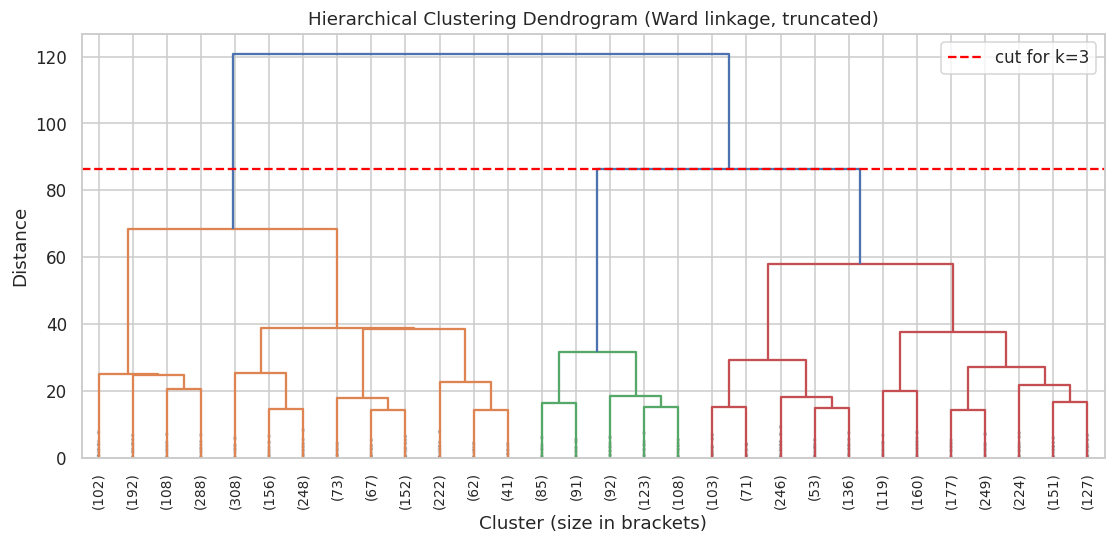

Hier_Cluster
0    2019
1     499
2    1816
Name: count, dtype: int64


In [10]:
Z = linkage(X, method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True)
cut_height = Z[-(K_OPT - 1), 2]
plt.axhline(cut_height, color="red", ls="--", label=f"cut for k={K_OPT}")
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, truncated)")
plt.xlabel("Cluster (size in brackets)"); plt.ylabel("Distance"); plt.legend(); plt.show()

hier_labels = fcluster(Z, t=K_OPT, criterion="maxclust") - 1
cust["Hier_Cluster"] = hier_labels
sil_h = silhouette_score(X, hier_labels)
print(cust["Hier_Cluster"].value_counts().sort_index())

## 10. Silhouette Score and Comparison of Clustering Results

,Method,k,Silhouette
0,K-Means,3,0.2759
1,Hierarchical (Ward),3,0.2517


Adjusted Rand Index between the two segmentations: 0.4863  (1 = identical)


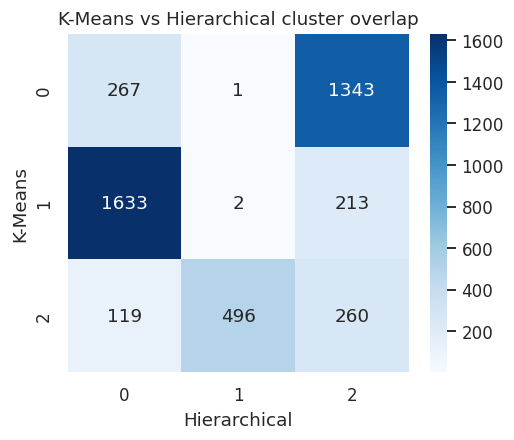

In [11]:
ari = adjusted_rand_score(cust["KMeans_Cluster"], cust["Hier_Cluster"])
comp = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical (Ward)"],
    "k": [K_OPT, K_OPT],
    "Silhouette": [sil_km, sil_h],
})
display(comp.round(4))
print(f"Adjusted Rand Index between the two segmentations: {ari:.4f}  (1 = identical)")

ct = pd.crosstab(cust["KMeans_Cluster"], cust["Hier_Cluster"], rownames=["K-Means"], colnames=["Hierarchical"])
plt.figure(figsize=(5, 4)); sns.heatmap(ct, annot=True, fmt="d", cmap="Blues")
plt.title("K-Means vs Hierarchical cluster overlap"); plt.show()

## 11. PCA: 2D Visualisation of Customer Segments

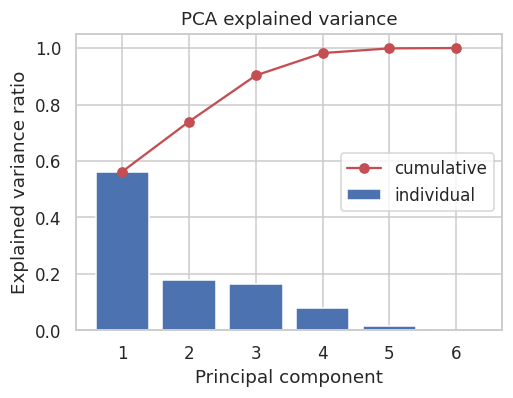

Variance explained by PC1+PC2: 74.0%


,PC1,PC2
Recency,-0.344,0.404
Frequency,0.456,-0.363
Monetary,0.532,0.111
AvgTransactionValue,0.348,0.604
TotalQuantity,0.519,0.102
PurchaseFrequency,0.032,-0.564


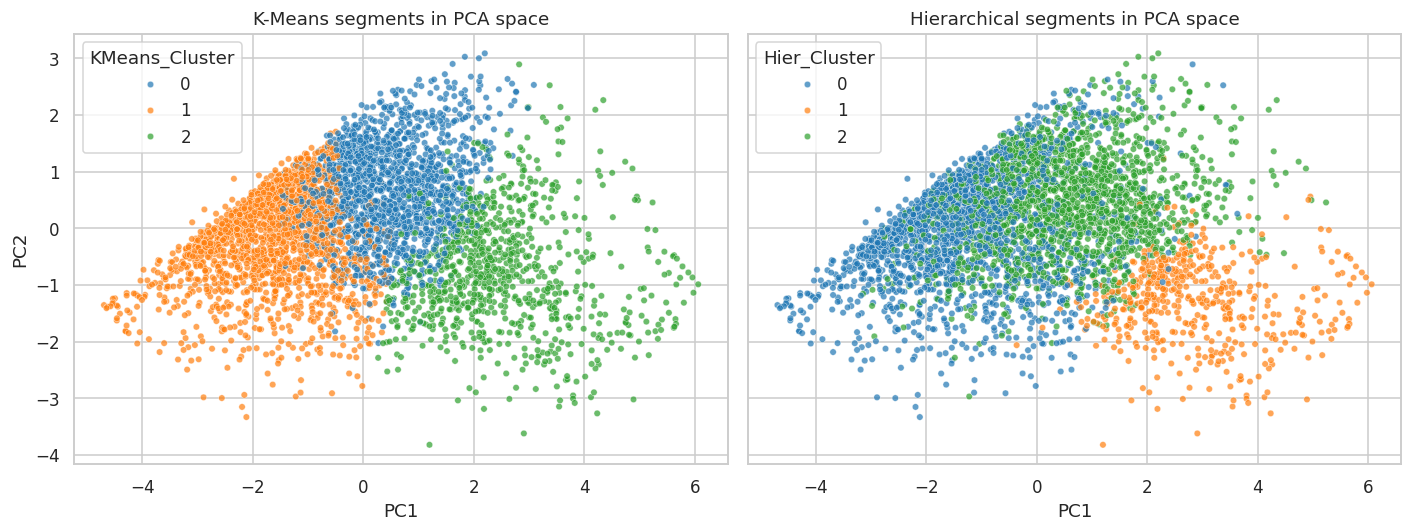

In [12]:
pca_full = PCA().fit(X)
ev = pca_full.explained_variance_ratio_
plt.figure(figsize=(5, 3.5))
plt.bar(range(1, len(ev) + 1), ev, label="individual"); plt.plot(range(1, len(ev) + 1), np.cumsum(ev), "ro-", label="cumulative")
plt.xlabel("Principal component"); plt.ylabel("Explained variance ratio"); plt.legend(); plt.title("PCA explained variance"); plt.show()

pca = PCA(n_components=2, random_state=RANDOM_STATE)
P = pca.fit_transform(X)
cust["PC1"], cust["PC2"] = P[:, 0], P[:, 1]
print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum():.1%}")

loadings = pd.DataFrame(pca.components_.T, index=cluster_features, columns=["PC1", "PC2"]).round(3)
display(loadings)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for ax, col, title in zip(axes, ["KMeans_Cluster", "Hier_Cluster"], ["K-Means", "Hierarchical"]):
    sns.scatterplot(data=cust, x="PC1", y="PC2", hue=col, palette="tab10", s=18, alpha=0.7, ax=ax)
    ax.set_title(f"{title} segments in PCA space")
plt.tight_layout(); plt.show()

## 12. Cluster Profiling

In [13]:
profile = cust.groupby("KMeans_Cluster").agg(
    Customers=("Recency", "size"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    AvgTransactionValue=("AvgTransactionValue", "mean"),
    TotalQuantity=("TotalQuantity", "mean"),
    PurchaseFrequency=("PurchaseFrequency", "mean"),
    UniqueProducts=("UniqueProducts", "mean"),
).round(2)
profile["% Customers"] = (profile["Customers"] / profile["Customers"].sum() * 100).round(1)
profile["% Revenue"] = (cust.groupby("KMeans_Cluster")["Monetary"].sum() / cust["Monetary"].sum() * 100).round(1)
display(profile)

,Customers,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,PurchaseFrequency,UniqueProducts,% Customers,% Revenue
KMeans_Cluster,,,,,,,,,,
0,1611,63.14,3.26,1231.10,462.55,753.28,0.60,62.87,37.2,22.7
1,1848,151.98,1.45,303.34,227.25,174.50,1.13,21.99,42.6,6.4
2,875,21.93,11.97,7085.76,727.33,4121.03,1.60,142.08,20.2,70.9


,Segment,Customers,% Customers,% Revenue,Recency,Frequency,Monetary
KMeans_Cluster,,,,,,,
0,Potential Loyalists,1611,37.2,22.7,63.14,3.26,1231.10
1,Lost / Inactive,1848,42.6,6.4,151.98,1.45,303.34
2,Champions (High-Value),875,20.2,70.9,21.93,11.97,7085.76


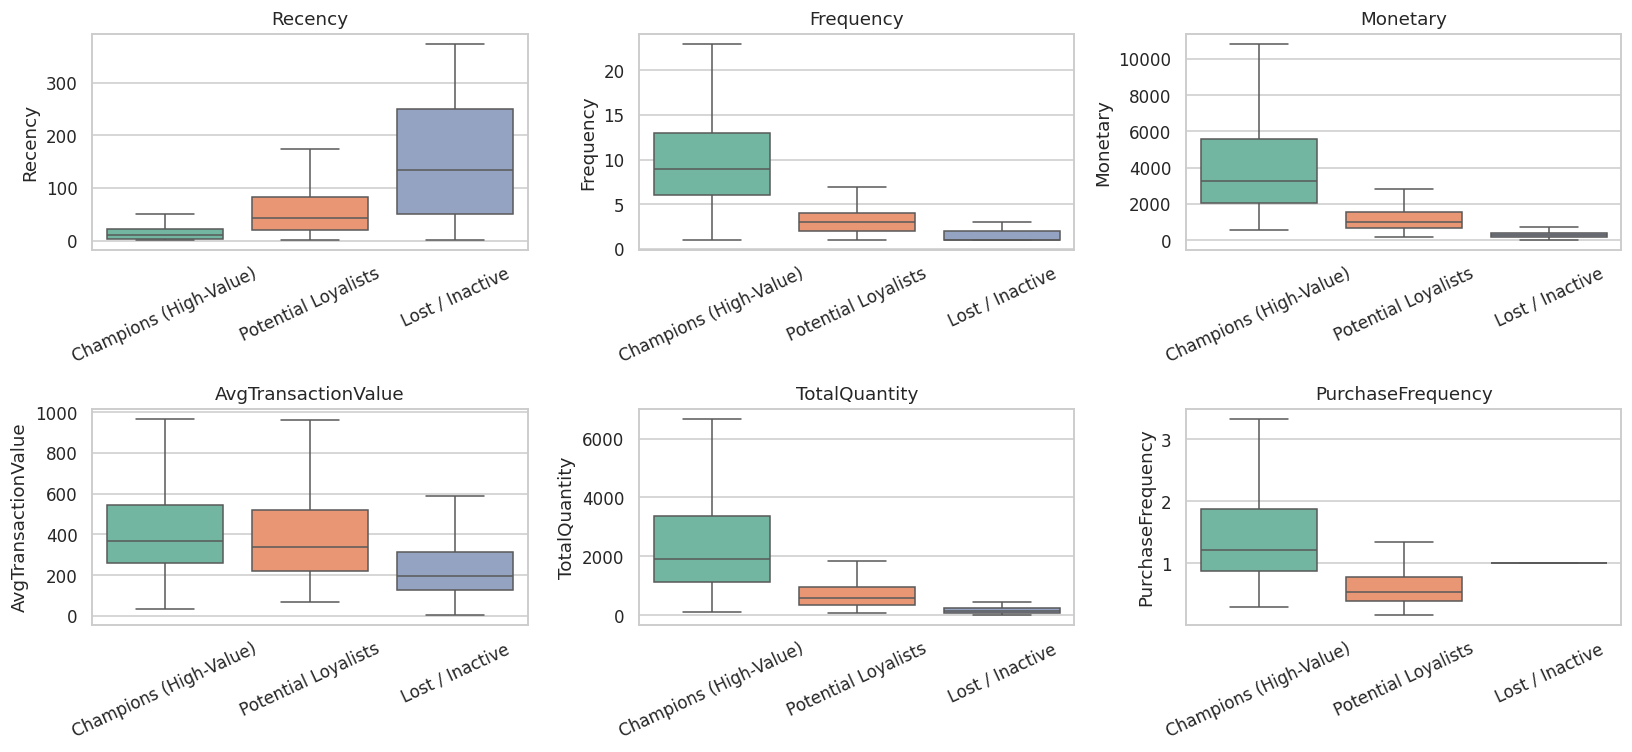

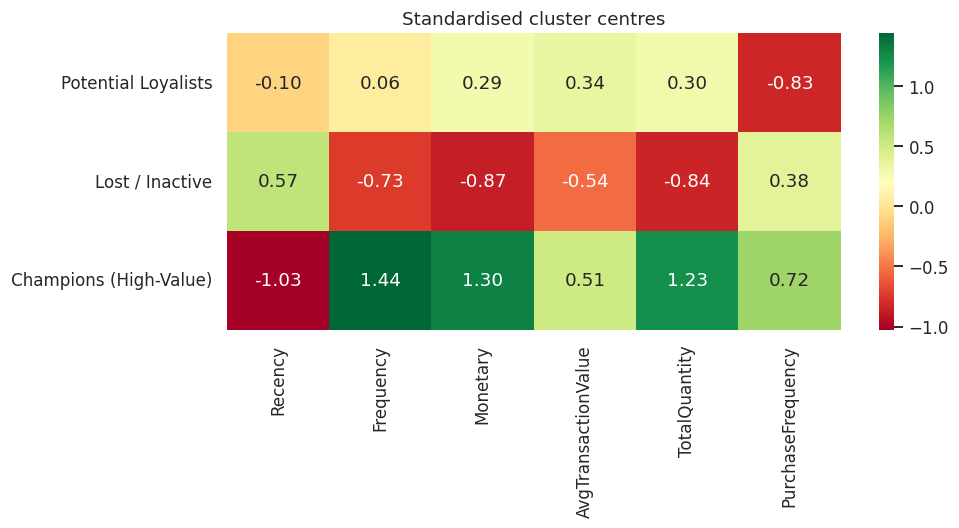

In [14]:
# Automatic, rule-based segment naming from RFM position (review and edit if needed)
z = (profile[["Recency", "Frequency", "Monetary"]] - profile[["Recency", "Frequency", "Monetary"]].mean()) / profile[["Recency", "Frequency", "Monetary"]].std(ddof=0)
score = z["Frequency"] + z["Monetary"] - z["Recency"]
order = score.sort_values(ascending=False).index.tolist()
median_rec = profile["Recency"].median()

base_name = {}
for i, c in enumerate(order):
    if i == 0: base_name[c] = "Champions (High-Value)"
    elif i == len(order) - 1: base_name[c] = "Lost / Inactive"
    elif profile.loc[c, "Recency"] <= median_rec: base_name[c] = "Potential Loyalists"
    else: base_name[c] = "At-Risk / Need Attention"

seen, seg_name = {}, {}
for c in sorted(base_name):
    n = base_name[c]; seen[n] = seen.get(n, 0) + 1
    seg_name[c] = n if list(base_name.values()).count(n) == 1 else f"{n} #{seen[n]}"

cust["Segment"] = cust["KMeans_Cluster"].map(seg_name)
profile["Segment"] = profile.index.map(seg_name)
display(profile[["Segment", "Customers", "% Customers", "% Revenue", "Recency", "Frequency", "Monetary"]])

fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.ravel(), ["Recency", "Frequency", "Monetary", "AvgTransactionValue", "TotalQuantity", "PurchaseFrequency"]):
    sns.boxplot(data=cust, x="Segment", y=c, ax=ax, showfliers=False, palette="Set2")
    ax.set_title(c); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=25)
plt.tight_layout(); plt.show()

# Heatmap of scaled cluster centres
centres = pd.DataFrame(X, columns=cluster_features).groupby(cust["KMeans_Cluster"].values).mean()
centres.index = [seg_name[i] for i in centres.index]
plt.figure(figsize=(9, 3.5)); sns.heatmap(centres, annot=True, fmt=".2f", cmap="RdYlGn"); plt.title("Standardised cluster centres"); plt.show()

## 13. Supervised Learning: Predicting High-Value Customers
**Target definition.** The high-value segment is the K-Means cluster with the highest average Monetary value (the *Champions* cluster). Target `HighValue = 1` if a customer belongs to it, else 0.

**Avoiding target leakage.** The clusters were *built* from Monetary (among others), so leaving Monetary in the predictors would make the task nearly trivial. We therefore **exclude `Monetary`** from the predictors and use the remaining behavioural features (plus `AvgQuantityPerInvoice` and `UniqueProducts`). This tests whether high-value status can be predicted from behaviour. Class imbalance is handled with `class_weight="balanced"`.

In [15]:
hv_cluster = profile["Monetary"].idxmax()
cust["HighValue"] = (cust["KMeans_Cluster"] == hv_cluster).astype(int)
print(f"High-value cluster: {hv_cluster} ({seg_name[hv_cluster]}) | share = {cust['HighValue'].mean():.1%}")

pred_features = ["Recency", "Frequency", "AvgTransactionValue", "TotalQuantity",
                 "AvgQuantityPerInvoice", "PurchaseFrequency", "UniqueProducts"]
Xs = np.log1p(cust[pred_features])          # log to tame skew; scaling happens inside the pipelines
y = cust["HighValue"]

X_train, X_test, y_train, y_test = train_test_split(Xs, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
print("Train:", X_train.shape, "Test:", X_test.shape, "| positives in test:", int(y_test.sum()))

High-value cluster: 2 (Champions (High-Value)) | share = 20.2%
Train: (3250, 7) Test: (1084, 7) | positives in test: 219


In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rf_pipe = Pipeline([("scale", StandardScaler()),
                    ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))])
rf_grid = {"clf__n_estimators": [200, 400], "clf__max_depth": [None, 8, 14], "clf__min_samples_leaf": [1, 3]}

svm_pipe = Pipeline([("scale", StandardScaler()),
                     ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced", random_state=RANDOM_STATE))])
svm_grid = {"clf__C": [0.5, 1, 5, 10], "clf__gamma": ["scale", 0.05, 0.2]}

models = {}
for name, pipe, grid in [("Random Forest", rf_pipe, rf_grid), ("SVM (RBF)", svm_pipe, svm_grid)]:
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="f1", n_jobs=-1).fit(X_train, y_train)
    models[name] = gs.best_estimator_
    print(f"{name}: best params = {gs.best_params_} | CV F1 = {gs.best_score_:.4f}")

Random Forest: best params = {'clf__max_depth': None, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 200} | CV F1 = 0.9460
SVM (RBF): best params = {'clf__C': 10, 'clf__gamma': 0.2} | CV F1 = 0.9745


## 14. Model Evaluation and Comparison

In [17]:
rows, probs = [], {}
for name, m in models.items():
    pred = m.predict(X_test); prob = m.predict_proba(X_test)[:, 1]; probs[name] = prob
    rows.append({"Model": name,
                 "Accuracy": accuracy_score(y_test, pred),
                 "Precision": precision_score(y_test, pred),
                 "Recall": recall_score(y_test, pred),
                 "F1-Score": f1_score(y_test, pred),
                 "ROC-AUC": roc_auc_score(y_test, prob)})
results = pd.DataFrame(rows).set_index("Model").round(4)
display(results)

for name, m in models.items():
    print(f"\n=== {name} ===")
    print(classification_report(y_test, m.predict(X_test), target_names=["Other", "High-Value"]))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.976,0.9488,0.9315,0.9401,0.9972
SVM (RBF),0.988,0.9682,0.9726,0.9704,0.9995



=== Random Forest ===
              precision    recall  f1-score   support

       Other       0.98      0.99      0.99       865
  High-Value       0.95      0.93      0.94       219

    accuracy                           0.98      1084
   macro avg       0.97      0.96      0.96      1084
weighted avg       0.98      0.98      0.98      1084


=== SVM (RBF) ===
              precision    recall  f1-score   support

       Other       0.99      0.99      0.99       865
  High-Value       0.97      0.97      0.97       219

    accuracy                           0.99      1084
   macro avg       0.98      0.98      0.98      1084
weighted avg       0.99      0.99      0.99      1084



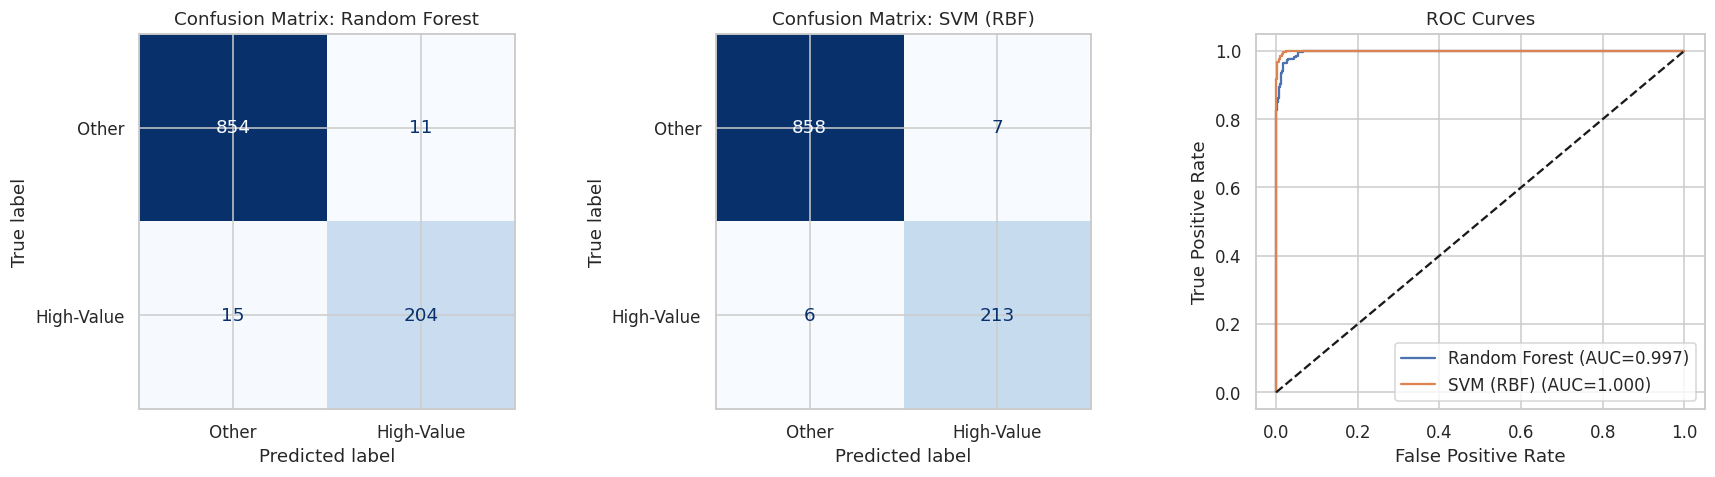

{'Random Forest': '0.9977 +/- 0.0007', 'SVM (RBF)': '0.9996 +/- 0.0002'} (5-fold ROC-AUC, on full data)


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, m) in zip(axes[:2], models.items()):
    ConfusionMatrixDisplay(confusion_matrix(y_test, m.predict(X_test)), display_labels=["Other", "High-Value"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Confusion Matrix: {name}")
for name, prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob); axes[2].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, prob):.3f})")
axes[2].plot([0, 1], [0, 1], "k--"); axes[2].set_xlabel("False Positive Rate"); axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("ROC Curves"); axes[2].legend()
plt.tight_layout(); plt.show()

cv_scores = {n: cross_val_score(m, Xs, y, cv=cv, scoring="roc_auc") for n, m in models.items()}
print({n: f"{s.mean():.4f} +/- {s.std():.4f}" for n, s in cv_scores.items()}, "(5-fold ROC-AUC, on full data)")

## 15. Feature Importance Analysis

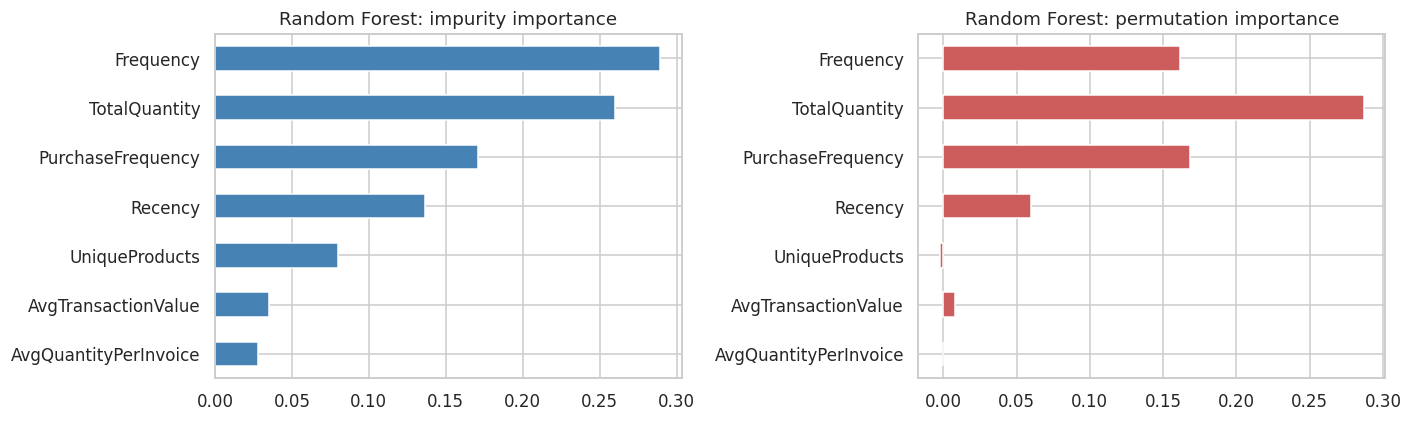

,Impurity importance,Permutation importance (F1 drop)
Frequency,0.2890,0.1617
TotalQuantity,0.2598,0.2870
PurchaseFrequency,0.1713,0.1682
Recency,0.1367,0.0599
UniqueProducts,0.0800,-0.0025
AvgTransactionValue,0.0353,0.0077
AvgQuantityPerInvoice,0.0279,-0.0002


In [19]:
rf = models["Random Forest"].named_steps["clf"]
imp = pd.DataFrame({"Impurity importance": rf.feature_importances_}, index=pred_features)
perm = permutation_importance(models["Random Forest"], X_test, y_test, scoring="f1", n_repeats=20, random_state=RANDOM_STATE, n_jobs=-1)
imp["Permutation importance (F1 drop)"] = perm.importances_mean
imp = imp.sort_values("Impurity importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
imp["Impurity importance"].plot.barh(ax=axes[0], color="steelblue", title="Random Forest: impurity importance")
imp["Permutation importance (F1 drop)"].plot.barh(ax=axes[1], color="indianred", title="Random Forest: permutation importance")
plt.tight_layout(); plt.show()
display(imp.sort_values("Impurity importance", ascending=False).round(4))

## 16. Interactive 3D Visualisation of Customer Clusters (Plotly)

In [20]:
plot_df = cust.reset_index().rename(columns={"index": "CustomerID"})
for c in ["Recency", "Frequency", "Monetary"]:
    plot_df[f"log_{c}"] = np.log10(plot_df[c] + 1)

fig = px.scatter_3d(plot_df, x="log_Recency", y="log_Frequency", z="log_Monetary", color="Segment",
                    hover_data=["CustomerID", "Recency", "Frequency", "Monetary"], opacity=0.75, size_max=6,
                    title="Customer Segments in log(RFM) space")
fig.update_traces(marker=dict(size=3))
fig.update_layout(height=650, scene=dict(xaxis_title="log10 Recency", yaxis_title="log10 Frequency", zaxis_title="log10 Monetary"))
fig.show()

In [21]:
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
P3 = pca3.fit_transform(X)
p3 = pd.DataFrame(P3, columns=["PC1", "PC2", "PC3"]); p3["Segment"] = cust["Segment"].values; p3["CustomerID"] = cust.index
fig2 = px.scatter_3d(p3, x="PC1", y="PC2", z="PC3", color="Segment", hover_data=["CustomerID"], opacity=0.75,
                     title=f"3D PCA projection ({pca3.explained_variance_ratio_.sum():.1%} variance explained)")
fig2.update_traces(marker=dict(size=3)); fig2.update_layout(height=650)
fig2.show()

## 17. Segment-wise Targeted Marketing Recommendations

In [22]:
strategies = {
    "Champions (High-Value)": [
        "Launch a VIP / loyalty tier with early access to new products and exclusive offers.",
        "Offer personalised bundles and premium bulk-purchase discounts; avoid blanket discounts, since they already buy at full price.",
        "Ask for reviews and referrals: use them as brand advocates.",
    ],
    "Potential Loyalists": [
        "Run post-purchase onboarding and cross-sell emails based on products bought.",
        "Offer points or membership incentives that reward a second/third purchase within a fixed window.",
        "Use free-shipping thresholds slightly above their average basket to grow order value.",
    ],
    "At-Risk / Need Attention": [
        "Send win-back campaigns (\"we miss you\" emails, time-limited coupons) before they lapse completely.",
        "Trigger reminders based on their usual purchase interval and show recently viewed or bought categories.",
        "Survey them briefly to learn why activity has dropped.",
    ],
    "Lost / Inactive": [
        "Run low-cost, low-frequency reactivation (deep-discount or clearance email) and cap spend per customer.",
        "Sunset unresponsive contacts from paid campaigns to protect deliverability and budget.",
        "Analyse exit patterns (last products bought, country) to fix root causes.",
    ],
}

for c in order:
    nm = seg_name[c]; base = base_name[c]; r = profile.loc[c]
    print(f"\n### {nm}  (cluster {c}): {int(r['Customers'])} customers, {r['% Customers']}% of base, {r['% Revenue']}% of revenue")
    print(f"    Avg recency {r['Recency']:.0f} days | frequency {r['Frequency']:.1f} orders | spend {r['Monetary']:.0f} GBP")
    for s in strategies[base]: print("   -", s)


### Champions (High-Value)  (cluster 2): 875 customers, 20.2% of base, 70.9% of revenue
    Avg recency 22 days | frequency 12.0 orders | spend 7086 GBP
   - Launch a VIP / loyalty tier with early access to new products and exclusive offers.
   - Offer personalised bundles and premium bulk-purchase discounts; avoid blanket discounts, since they already buy at full price.
   - Ask for reviews and referrals: use them as brand advocates.

### Potential Loyalists  (cluster 0): 1611 customers, 37.2% of base, 22.7% of revenue
    Avg recency 63 days | frequency 3.3 orders | spend 1231 GBP
   - Run post-purchase onboarding and cross-sell emails based on products bought.
   - Offer points or membership incentives that reward a second/third purchase within a fixed window.
   - Use free-shipping thresholds slightly above their average basket to grow order value.

### Lost / Inactive  (cluster 1): 1848 customers, 42.6% of base, 6.4% of revenue
    Avg recency 152 days | frequency 1.4 orders | sp

## 18. Interpretation of Results
> *Fill in with your own numbers after running the notebook; the points below indicate what to discuss.*

- **Number of clusters:** state the elbow location and the silhouette values, and explain why `K_OPT` was chosen.
- **K-Means vs Hierarchical:** compare silhouette scores and the Adjusted Rand Index; note where the two methods disagree (the crosstab heatmap) and that K-Means scales better while the dendrogram gives extra insight into cluster structure.
- **PCA:** report the variance explained by PC1+PC2 and which features load onto each component (spend/frequency vs recency); comment on how well separated the segments look.
- **Profiles:** which segment holds the biggest share of revenue relative to its size (Pareto effect)?
- **Classification:** compare Random Forest and SVM on Precision, Recall, F1 and ROC-AUC; explain which error (false positive or false negative) matters more for marketing and why.
- **Feature importance:** which behavioural features (typically Frequency, PurchaseFrequency, TotalQuantity) drive high-value status.
- **Limitations:** single retailer, one year of data, the label comes from an unsupervised clustering (so it depends on the chosen k and features), and `Monetary` was excluded to prevent leakage.

## 19. Conclusion
The pipeline cleaned 541,909 raw transactions into customer-level RFM-style features, segmented customers with K-Means (validated with the Elbow Method, Silhouette Score, hierarchical clustering and PCA), profiled each segment, and trained Random Forest and SVM models that predict membership in the high-value segment from behavioural features. The results support differentiated marketing: retain and reward Champions, nurture Potential Loyalists, win back At-Risk customers and contain the cost of re-engaging Lost customers.

**Git repository:** _paste link here_